# Compare real data vs simulations for Abell 360 (a360)

Loads the merged AnaCal catalogs from two butler collections:
- `u/xiangchl/dp1/a360_anacal_coadd` — real ComCam coadds (MeasureCoaddsPipe)
- `u/xiangchl/dp1/a360_anacal_sim_coadd_80_0` — image simulations under deep-coadd
  systematics: `catsim2017` (dc1), `flagship2025`, and `diffsky` sims

Bands available: g, r, i, z. Magnitude flux source is selectable via
`FLUX_KIND` (`fpfs1`, `gauss0`, `gauss2`, `gauss4`).

In [1]:
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors

from astropy.table import Table, vstack
from lsst.daf.butler import Butler

BIGGER_SIZE = 20
plt.rc("font", size=BIGGER_SIZE)
plt.rc("axes", titlesize=BIGGER_SIZE)
plt.rc("axes", labelsize=BIGGER_SIZE)
plt.rc("xtick", labelsize=BIGGER_SIZE)
plt.rc("ytick", labelsize=BIGGER_SIZE)
plt.rc("legend", fontsize=BIGGER_SIZE)
plt.rc("figure", titlesize=BIGGER_SIZE)

In [25]:
FLUX_KIND = "fpfs1"

def flux_col(band: str, kind: str = FLUX_KIND) -> str:
    return f"{band}_flux_{kind}"


def flux_to_mag(flux, mag_zero=31.4):
    flux = np.asarray(flux)
    return mag_zero - 2.5 * np.log10(flux)


print(f"Using flux source: {FLUX_KIND}  (column pattern: '{{band}}_flux_{FLUX_KIND}')")

Using flux source: fpfs1  (column pattern: '{band}_flux_fpfs1')


In [26]:
REPO = "/global/cfs/cdirs/lsst/production/gen3/rubin/DP1/repo/butler.yaml"
COLL_DATA = "u/xiangchl/dp1/a360_anacal_coadd"
COLL_SIM = "u/xiangchl/dp1/a360_anacal_sim_coadd_80_0"

# Per-patch anacal_catalogs (have per-band shapelet moments + ra/dec + flux).
DSTYPE_DATA = "deep_coadd_anacal_catalog"                         # measure_pipeline_coadd outputs
DSTYPE_SIM = "deep_dc1_coadd_cell_80_0_anacal_catalog"            # catsim2017 sim outputs
DSTYPE_FLAGSHIP = "deep_flagship_coadd_cell_80_0_anacal_catalog"  # flagship2025 sim outputs
DSTYPE_DIFFSKY = "deep_diffsky_coadd_cell_80_0_anacal_catalog"    # diffsky sim outputs

butler_data = Butler(REPO, collections=COLL_DATA)
butler_sim = Butler(REPO, collections=COLL_SIM)


def load_anacal(butler, dataset_type):
    """vstack all per-patch anacal_catalog refs and keep only is_primary=True rows."""
    refs = list(set(butler.registry.queryDatasets(dataset_type)))
    if len(refs) == 0:
        raise RuntimeError(f"no {dataset_type} datasets found in {butler.collections}")
    tables = [Table(butler.get(ref)) for ref in refs]
    cat = vstack(tables)
    cat = cat[cat["is_primary"]]
    return cat


data = load_anacal(butler_data, DSTYPE_DATA)
sim = load_anacal(butler_sim, DSTYPE_SIM)
flagship = load_anacal(butler_sim, DSTYPE_FLAGSHIP)
diffsky = load_anacal(butler_sim, DSTYPE_DIFFSKY)
print(f"data:     {len(data):,} rows")
print(f"catsim:   {len(sim):,} rows")
print(f"flagship: {len(flagship):,} rows")
print(f"diffsky:  {len(diffsky):,} rows")

for b in "griz":
    for name, cat in [("data", data), ("catsim", sim), ("flagship", flagship), ("diffsky", diffsky)]:
        if flux_col(b) not in cat.colnames:
            raise KeyError(f"column {flux_col(b)!r} not in {name} catalog (FLUX_KIND={FLUX_KIND})")

data:     135,392 rows
catsim:   128,480 rows
flagship: 124,806 rows
diffsky:  120,450 rows


In [27]:
def _select(t):
    return (
        ((31.4 - 2.5 * np.log10(t[flux_col("i")])) < 24.5)
        & ((31.4 - 2.5 * np.log10(t[flux_col("g")])) < 26.0)
        & ((31.4 - 2.5 * np.log10(t[flux_col("r")])) < 25.0)
        & ((31.4 - 2.5 * np.log10(t[flux_col("z")])) < 25.0)
        & ((t["i_fpfs1_m00"] + t["i_fpfs1_m20"]) / t["i_fpfs1_m00"] > 0.08)
    )

sel1 = _select(data)
sel2 = _select(sim)
sel3 = _select(flagship)
sel4 = _select(diffsky)
print(f"selected: data={sel1.sum():,}, catsim={sel2.sum():,}, flagship={sel3.sum():,}, diffsky={sel4.sum():,}")

selected: data=59,242, catsim=57,114, flagship=59,442, diffsky=55,740


/tmp/ipykernel_1797272/1972231536.py:3: RuntimeWarning: invalid value encountered in log10
  ((31.4 - 2.5 * np.log10(t[flux_col("i")])) < 24.5)
/tmp/ipykernel_1797272/1972231536.py:4: RuntimeWarning: invalid value encountered in log10
  & ((31.4 - 2.5 * np.log10(t[flux_col("g")])) < 26.0)
/tmp/ipykernel_1797272/1972231536.py:5: RuntimeWarning: invalid value encountered in log10
  & ((31.4 - 2.5 * np.log10(t[flux_col("r")])) < 25.0)
/tmp/ipykernel_1797272/1972231536.py:6: RuntimeWarning: invalid value encountered in log10
  & ((31.4 - 2.5 * np.log10(t[flux_col("z")])) < 25.0)


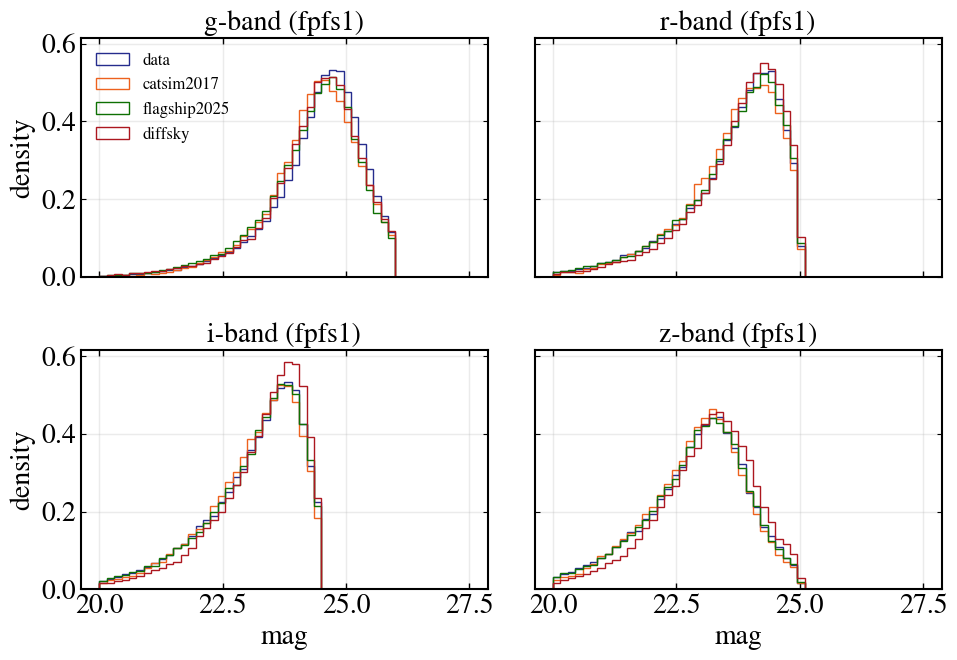

In [28]:
bands = "griz"
mag_zero = 31.4
bins = 50
mag_range = (20, 27.5)

fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)
axes = axes.ravel()

for i, b in enumerate(bands):
    ax = axes[i]
    for cat, mask, label in [
        (data, sel1, "data"),
        (sim, sel2, "catsim2017"),
        (flagship, sel3, "flagship2025"),
        (diffsky, sel4, "diffsky"),
    ]:
        f = np.asarray(cat[flux_col(b)])[mask]
        m = np.isfinite(f) & (f > 0)
        ax.hist(flux_to_mag(f[m], mag_zero=mag_zero),
                histtype="step", bins=bins, density=True,
                range=mag_range, label=label)
    ax.set_title(f"{b}-band ({FLUX_KIND})")
    ax.grid(True, alpha=0.25)
    if i % 2 == 0:
        ax.set_ylabel("density")
    if i >= 2:
        ax.set_xlabel("mag")

axes[0].legend(loc="upper left", frameon=False, fontsize=12)
fig.tight_layout()
plt.show()

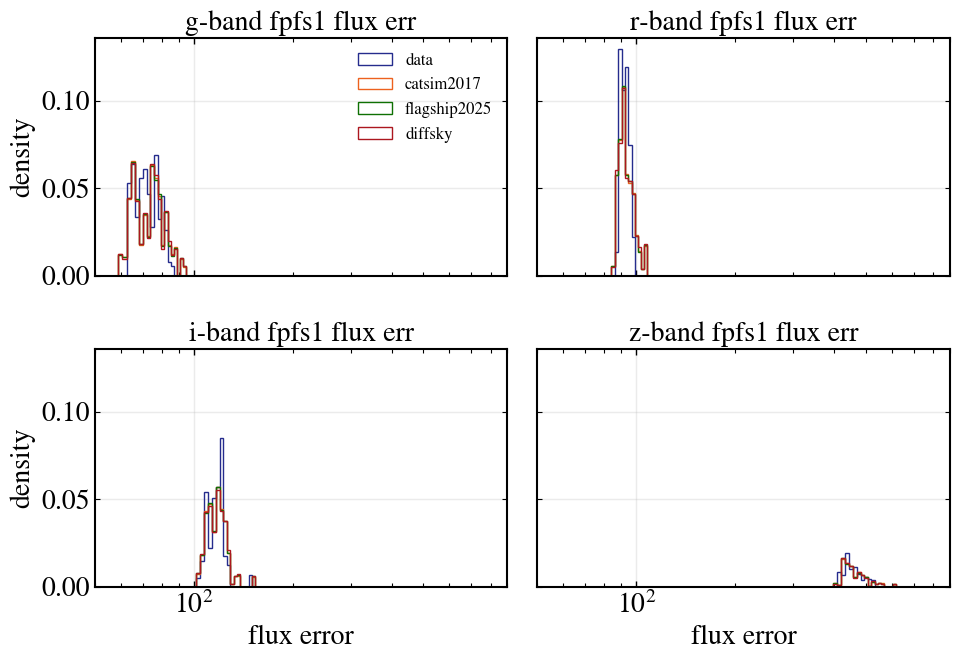

In [29]:
# 1D histograms of fpfs1 flux uncertainty per band (column: '{band}_flux_fpfs1_err').
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)
axes = axes.ravel()

for i, b in enumerate(bands):
    ax = axes[i]
    col = f"{b}_flux_fpfs1_err"
    series = []
    for cat, mask, label in [
        (data, sel1, "data"),
        (sim, sel2, "catsim2017"),
        (flagship, sel3, "flagship2025"),
        (diffsky, sel4, "diffsky"),
    ]:
        e = np.asarray(cat[col])[mask]
        m = np.isfinite(e) & (e > 0)
        series.append((e[m], label))

    p99 = np.nanpercentile(np.concatenate([e for e, _ in series]), 99)
    rng = (0.0, p99)
    for e, label in series:
        ax.hist(e, histtype="step", bins=50, density=True, range=rng, label=label)
    ax.set_title(f"{b}-band fpfs1 flux err")
    ax.grid(True, alpha=0.25)
    ax.set_xscale("log")
    ax.set_xlim(50, 900)
    if i % 2 == 0:
        ax.set_ylabel("density")
    if i >= 2:
        ax.set_xlabel("flux error")

axes[0].legend(loc="upper right", frameon=False, fontsize=12)
fig.tight_layout()
plt.show()

In [30]:
# Build per-band magnitude dictionaries for the 2D plots below.
dd = {}   # real data
ss = {}   # catsim2017 sim
ff = {}   # flagship2025 sim
df = {}   # diffsky sim
for b in bands:
    dd[b] = mag_zero - 2.5 * np.log10(np.asarray(data[flux_col(b)])[sel1])
    ss[b] = mag_zero - 2.5 * np.log10(np.asarray(sim[flux_col(b)])[sel2])
    ff[b] = mag_zero - 2.5 * np.log10(np.asarray(flagship[flux_col(b)])[sel3])
    df[b] = mag_zero - 2.5 * np.log10(np.asarray(diffsky[flux_col(b)])[sel4])

In [31]:
from matplotlib.lines import Line2D


class corner_plot:
    def __init__(self, xrange, yrange, bins=30, xlabel="x", ylabel="y", xlim=None, ylim=None):
        fig = plt.figure(figsize=(8, 8))
        gs = fig.add_gridspec(4, 4, wspace=0.05, hspace=0.05)
        self.ax_2d = fig.add_subplot(gs[1:4, 0:3])
        self.ax_2d.set_xlabel(xlabel)
        self.ax_2d.set_ylabel(ylabel)

        self.ax_top = fig.add_subplot(gs[0, 0:3], sharex=self.ax_2d)
        self.ax_top.set_ylabel("PDF")
        self.ax_top.tick_params(axis="x", labelbottom=False)

        self.ax_right = fig.add_subplot(gs[1:4, 3], sharey=self.ax_2d)
        self.ax_right.set_xlabel("PDF")
        self.ax_right.tick_params(axis="y", labelleft=False)

        self.range_2d = [xrange, yrange]
        self.range_x = xrange
        self.range_y = yrange
        self.bins = bins

        if xlim is None:
            xlim = self.range_x
        if ylim is None:
            ylim = self.range_y
        self.ax_2d.set_xlim(xlim)
        self.ax_2d.set_ylim(ylim)
        self.ax_top.set_xlim(xlim)
        self.ax_right.set_ylim(ylim)

        self._legend_handles = []

    def make_plot(self, x_array, y_array, linestyles="-", levels=[0.1, 0.3, 0.6], label=None):
        hist, xedges, yedges = np.histogram2d(
            x=x_array, y=y_array, bins=self.bins,
            range=self.range_2d, density=True,
        )
        xcenters = 0.5 * (xedges[:-1] + xedges[1:])
        ycenters = 0.5 * (yedges[:-1] + yedges[1:])
        X, Y = np.meshgrid(xcenters, ycenters)

        self.ax_2d.contour(
            X, Y, hist.T, levels=levels,
            colors="black", linestyles=linestyles,
        )
        self.ax_top.hist(
            x_array, bins=self.bins, histtype="step", color="black",
            range=self.range_x, density=True, ls=linestyles,
        )
        self.ax_right.hist(
            y_array, bins=self.bins, histtype="step", color="black",
            range=self.range_y, density=True,
            ls=linestyles, orientation="horizontal",
        )
        if label is not None:
            self._legend_handles.append(
                Line2D([0], [0], color="black", linestyle=linestyles, label=label)
            )
        plt.tight_layout()

    def legend(self, loc="upper right", fontsize=14, frameon=False):
        if self._legend_handles:
            self.ax_2d.legend(handles=self._legend_handles,
                              loc=loc, fontsize=fontsize, frameon=frameon)

/tmp/ipykernel_1797272/3105865032.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


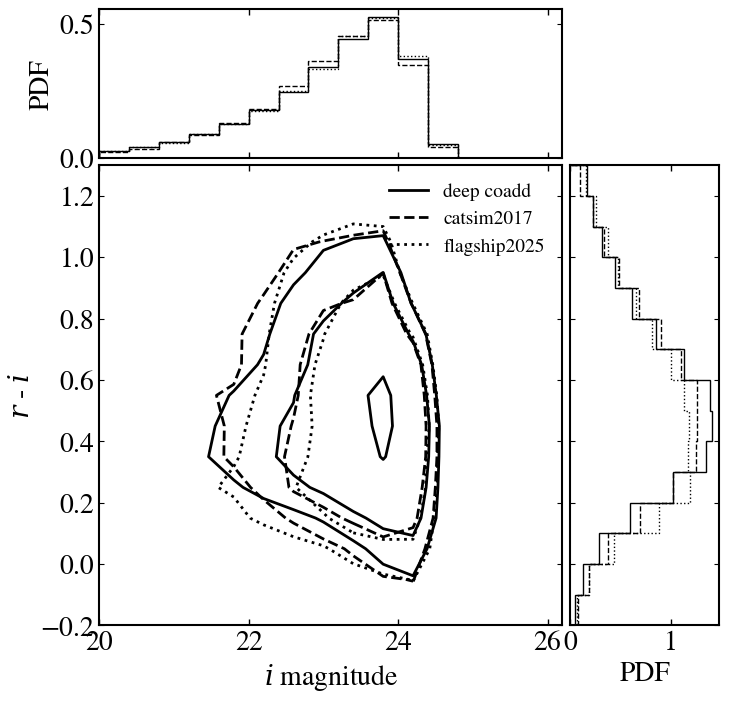

In [34]:
# 2D: r - i  vs  i magnitude.
plt.close()
corp = corner_plot(
    xrange=[20.0, 26.0], yrange=[-0.2, 1.3], bins=15,
    xlabel=rf"$i$ magnitude", ylabel=r"$r$ - $i$",
    xlim=[20, 26.2], ylim=[-0.2, 1.3],
)
corp.make_plot(x_array=dd["i"], y_array=dd["r"] - dd["i"], linestyles="-",  levels=[0.15, 0.3, 0.65], label="deep coadd")
corp.make_plot(x_array=ss["i"], y_array=ss["r"] - ss["i"], linestyles="--", levels=[0.15, 0.3, 0.65], label="catsim2017")
corp.make_plot(x_array=ff["i"], y_array=ff["r"] - ff["i"], linestyles=":",  levels=[0.15, 0.3, 0.65], label="flagship2025")
#corp.make_plot(x_array=df["i"], y_array=df["r"] - df["i"], linestyles="-.", levels=[0.15, 0.3, 0.65], label="diffsky")
corp.legend(loc="upper right")

/tmp/ipykernel_1797272/3105865032.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


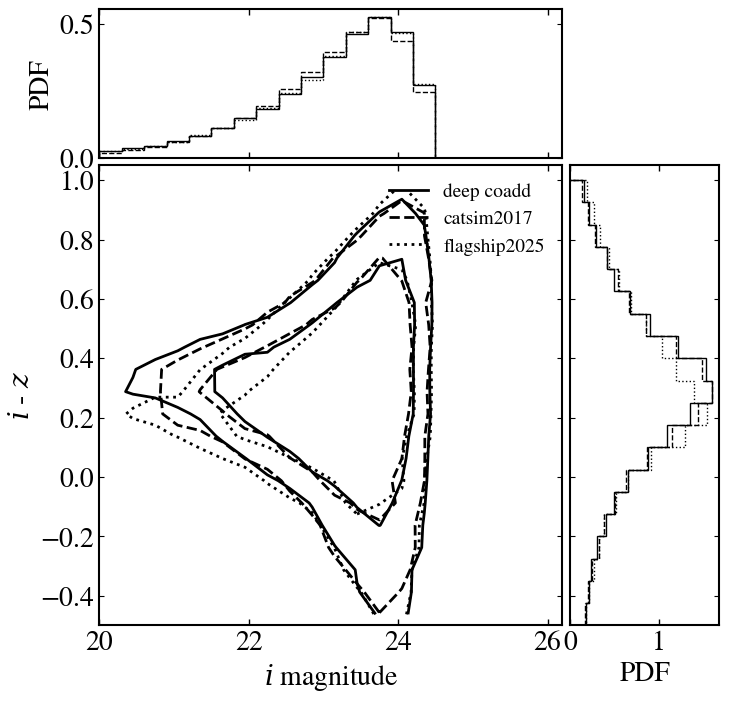

In [35]:
# 2D: i - z  vs  i magnitude.
plt.close()
corp = corner_plot(
    xrange=[20.0, 26.0], yrange=[-0.5, 1.0], bins=20,
    xlabel=rf"$i$ magnitude", ylabel=r"$i$ - $z$",
    xlim=[20, 26.2], ylim=[-0.5, 1.05],
)
corp.make_plot(x_array=dd["i"], y_array=dd["i"] - dd["z"], linestyles="-",  levels=[0.15, 0.3, 0.65], label="deep coadd")
corp.make_plot(x_array=ss["i"], y_array=ss["i"] - ss["z"], linestyles="--", levels=[0.15, 0.3, 0.65], label="catsim2017")
corp.make_plot(x_array=ff["i"], y_array=ff["i"] - ff["z"], linestyles=":",  levels=[0.15, 0.3, 0.65], label="flagship2025")
#corp.make_plot(x_array=df["i"], y_array=df["i"] - df["z"], linestyles="-.", levels=[0.15, 0.3, 0.65], label="diffsky")
corp.legend(loc="upper right")

In [ ]:
# 2D: i-band size  vs  i magnitude.
plt.close()
corp = corner_plot(
    xrange=[20.0, 26.0], yrange=[0.1, 1.2], bins=20,
    xlabel=rf"$i$ magnitude ({FLUX_KIND})", ylabel=r"$i$-band size [arcsec]",
    xlim=[20.0, 26.5], ylim=[0.1, 1.2],
)

# i-band size from the per-patch anacal_catalog (per-band shapelet moments).
_size_data = ((data["i_fpfs1_m00"][sel1] + data["i_fpfs1_m20"][sel1]) / data["i_fpfs1_m00"][sel1]) ** 0.5
_size_sim = ((sim["i_fpfs1_m00"][sel2] + sim["i_fpfs1_m20"][sel2]) / sim["i_fpfs1_m00"][sel2]) ** 0.5
_size_flag = ((flagship["i_fpfs1_m00"][sel3] + flagship["i_fpfs1_m20"][sel3]) / flagship["i_fpfs1_m00"][sel3]) ** 0.5
_size_diff = ((diffsky["i_fpfs1_m00"][sel4] + diffsky["i_fpfs1_m20"][sel4]) / diffsky["i_fpfs1_m00"][sel4]) ** 0.5

corp.make_plot(x_array=dd["i"], y_array=_size_data, linestyles="-",  levels=[0.2, 0.4, 0.8], label="deep coadd")
corp.make_plot(x_array=ss["i"], y_array=_size_sim,  linestyles="--", levels=[0.2, 0.4, 0.8], label="catsim2017")
corp.make_plot(x_array=ff["i"], y_array=_size_flag, linestyles=":",  levels=[0.2, 0.4, 0.8], label="flagship2025")
#corp.make_plot(x_array=df["i"], y_array=_size_diff, linestyles="-.", levels=[0.2, 0.4, 0.8], label="diffsky")
corp.legend(loc="upper right")

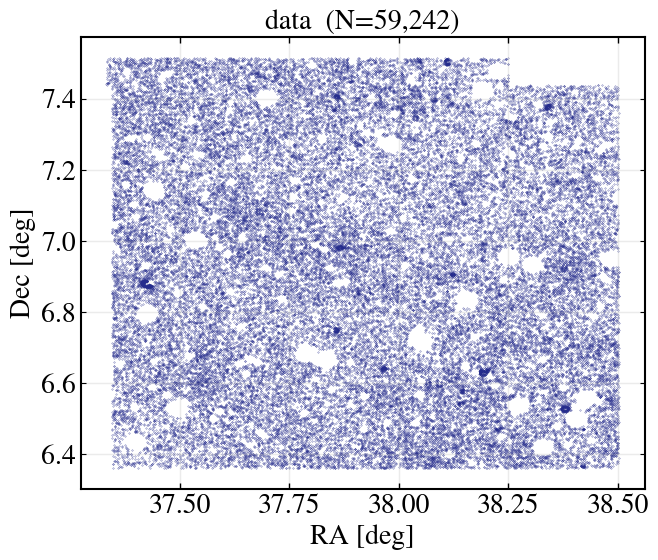

In [12]:
# RA / Dec scatter — real data.
plt.close()
plt.figure(figsize=(7, 6))
plt.scatter(data["ra"][sel1], data["dec"][sel1], s=0.05)
plt.xlabel("RA [deg]"); plt.ylabel("Dec [deg]")
plt.title(f"data  (N={sel1.sum():,})")
plt.grid(True, alpha=0.25); plt.tight_layout(); plt.show()

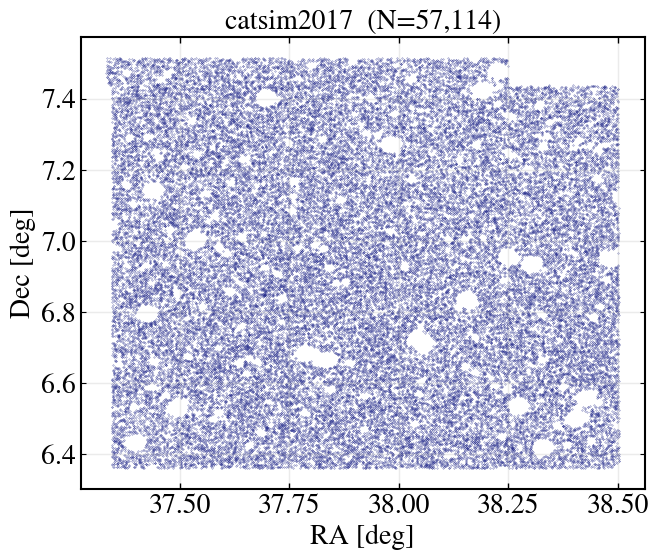

In [13]:
# RA / Dec scatter — catsim2017 sim.
plt.close()
plt.figure(figsize=(7, 6))
plt.scatter(sim["ra"][sel2], sim["dec"][sel2], s=0.05)
plt.xlabel("RA [deg]"); plt.ylabel("Dec [deg]")
plt.title(f"catsim2017  (N={sel2.sum():,})")
plt.grid(True, alpha=0.25); plt.tight_layout(); plt.show()

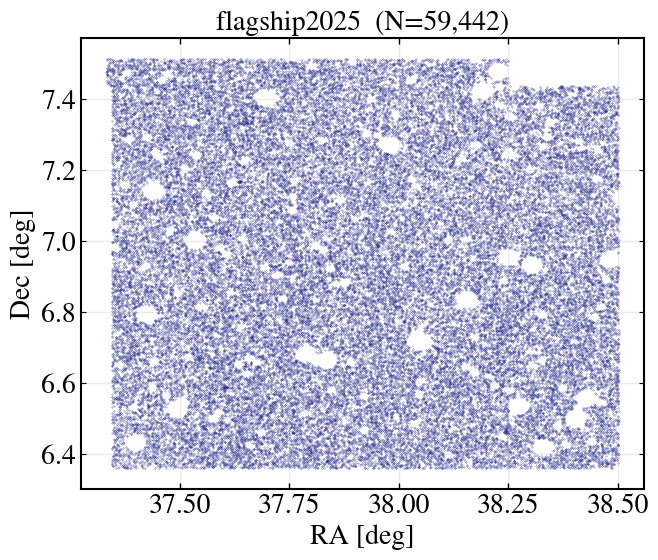

In [14]:
# RA / Dec scatter — flagship2025 sim.
plt.close()
plt.figure(figsize=(7, 6))
plt.scatter(flagship["ra"][sel3], flagship["dec"][sel3], s=0.05)
plt.xlabel("RA [deg]"); plt.ylabel("Dec [deg]")
plt.title(f"flagship2025  (N={sel3.sum():,})")
plt.grid(True, alpha=0.25); plt.tight_layout(); plt.show()

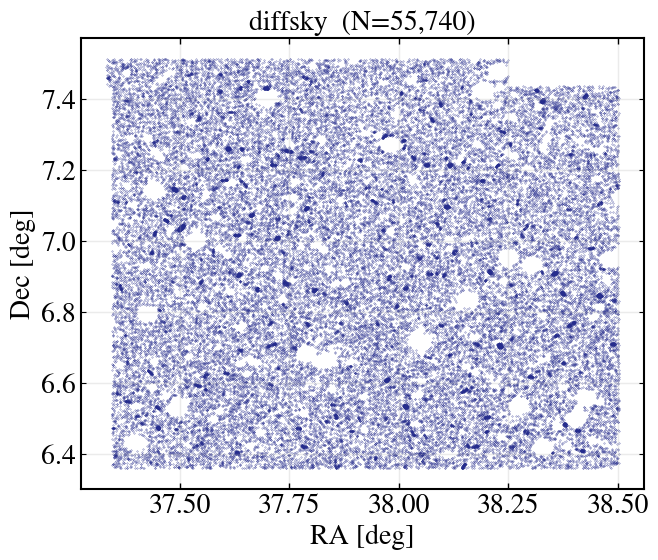

In [15]:
# RA / Dec scatter — diffsky sim.
plt.close()
plt.figure(figsize=(7, 6))
plt.scatter(diffsky["ra"][sel4], diffsky["dec"][sel4], s=0.05)
plt.xlabel("RA [deg]"); plt.ylabel("Dec [deg]")
plt.title(f"diffsky  (N={sel4.sum():,})")
plt.grid(True, alpha=0.25); plt.tight_layout(); plt.show()